In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


df = pd.read_csv('data/Food_Delivery_Times.csv')

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df = df.drop_duplicates()

In [5]:
df.shape

(1000, 9)

In [6]:
df = df.drop(columns=['Order_ID'])
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 970 non-null    str    
 2   Traffic_Level           970 non-null    str    
 3   Time_of_Day             970 non-null    str    
 4   Vehicle_Type            1000 non-null   str    
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  970 non-null    float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


In [8]:
fill_values = {
    'Weather': 'Clear',
    'Traffic_Level': 'Medium',
    'Time_of_Day': 'Evening',
    'Courier_Experience_yrs': 1
}
df = df.fillna(value=fill_values)
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 1000 non-null   str    
 2   Traffic_Level           1000 non-null   str    
 3   Time_of_Day             1000 non-null   str    
 4   Vehicle_Type            1000 non-null   str    
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  1000 non-null   int64  
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 62.6 KB


In [9]:
traffic_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Traffic_Level'] = df['Traffic_Level'].map(traffic_mapping)

norml_cols = ['Weather', 'Time_of_Day', 'Vehicle_Type']
df = pd.get_dummies(df, columns=norml_cols, dtype=int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Traffic_Level           1000 non-null   int64  
 2   Preparation_Time_min    1000 non-null   int64  
 3   Courier_Experience_yrs  1000 non-null   int64  
 4   Delivery_Time_min       1000 non-null   int64  
 5   Weather_Clear           1000 non-null   int64  
 6   Weather_Foggy           1000 non-null   int64  
 7   Weather_Rainy           1000 non-null   int64  
 8   Weather_Snowy           1000 non-null   int64  
 9   Weather_Windy           1000 non-null   int64  
 10  Time_of_Day_Afternoon   1000 non-null   int64  
 11  Time_of_Day_Evening     1000 non-null   int64  
 12  Time_of_Day_Morning     1000 non-null   int64  
 13  Time_of_Day_Night       1000 non-null   int64  
 14  Vehicle_Type_Bike       1000 non-null   int64  
 15 

In [10]:
df.columns

Index(['Distance_km', 'Traffic_Level', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min', 'Weather_Clear',
       'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'],
      dtype='str')

/tmp/ipykernel_7738/3316218656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


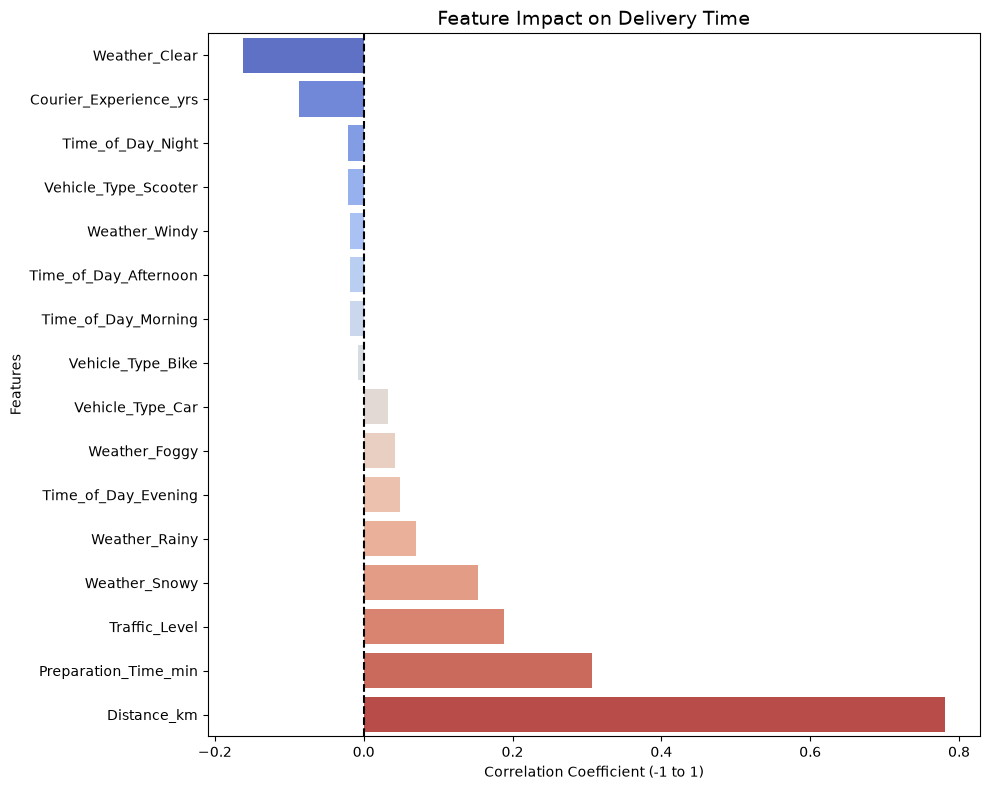

In [11]:
import seaborn as sns
plt.figure(figsize=(10, 8))
correlations = df.corr()['Delivery_Time_min'].drop('Delivery_Time_min').sort_values()
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

plt.title('Feature Impact on Delivery Time', fontsize=14)
plt.xlabel('Correlation Coefficient (-1 to 1)')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

In [13]:

df.to_csv('data/Food_Delivery_Times_Cleaned.csv', index=False)

NameError: name 'df' is not defined